# Hafta 6 — Parabolik ve Hiperbolik KDD'ler: Isı ve Dalga Denklemleri

> **Bilim İnsanları ve Mühendisler için Diferansiyel Denklemler**  
> *FTCS, Crank-Nicolson ve sıçrama (leapfrog) şeması — sıfırdan türetilir, kararlılık doğrulanır.*

---

## Öğrenme Hedefleri

1. **Isı denklemini** Fourier yasasından türetmek; değişkenleri analitik ayırmak
2. **FTCS**'yi (İleri-Zaman, Merkezi-Uzay) uygulamak ve **CFL kararlılık koşulunu** analiz etmek
3. Isı denklemi için **Crank-Nicolson**'u uygulamak (A-kararlı, zamanda 2. mertebe)
4. **Dalga denklemini** ve d'Alembert çözümünü türetmek
5. Dalga denklemi için **sıçrama (açık merkezi)** şemasını uygulamak
6. KDD çözümlerini animasyonlu yüzeyler ve uzay-zaman diyagramları olarak görselleştirmek


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'serif',
})

---

## 1. Isı Denklemi

Fourier'in ısı iletim yasası şuna yol açar:

$$\frac{\partial u}{\partial t} = \alpha\,\frac{\partial^2 u}{\partial x^2}, \quad x \in (0, L), \quad t > 0$$

başlangıç koşulu $u(x, 0) = u_0(x)$ ve sınır koşulları $u(0,t) = u(L,t) = 0$ ile.

**Değişkenlerine ayırma yoluyla analitik çözüm:**

$$u(x, t) = \sum_{n=1}^{\infty} B_n\,\sin\frac{n\pi x}{L}\,e^{-\alpha(n\pi/L)^2 t}$$

burada $B_n = \dfrac{2}{L}\int_0^L u_0(x)\sin\dfrac{n\pi x}{L}\,dx$.

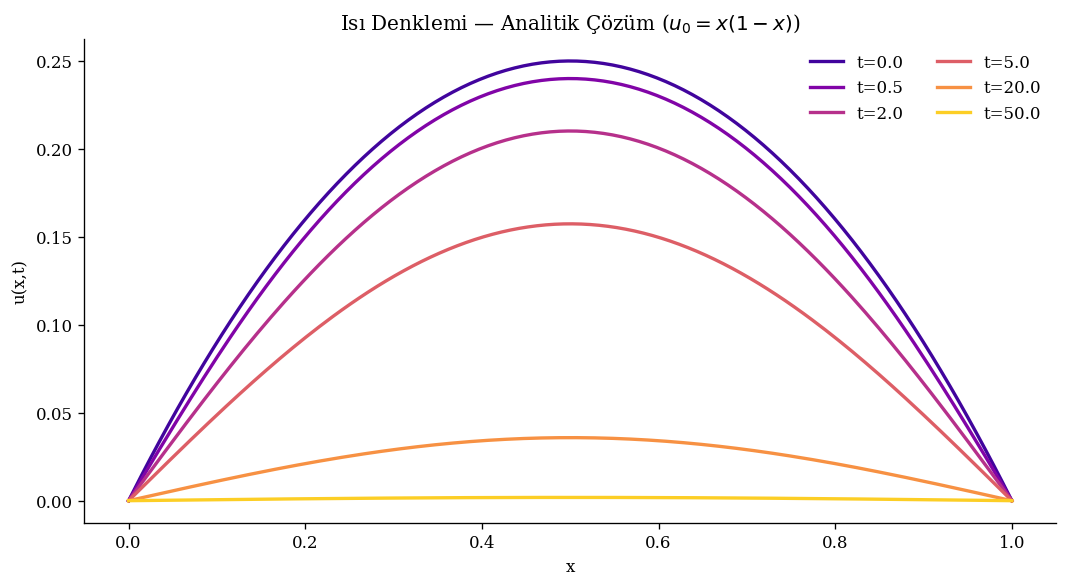

In [2]:
def isi_analitik(x, t, alpha, L, N_terim=50):
    """Isı denkleminin analitik Fourier serisi çözümü."""
    u = np.zeros_like(x, dtype=float)
    for n in range(1, N_terim+1):
        # u0(x) = x*(L-x) için:
        # B_n = (2/L) * integral_0^L x(L-x)sin(n*pi*x/L)dx
        # = (8L^2) / (n^3*pi^3)  tek n için, çift n için 0
        if n % 2 == 1:
            B_n = 8 * L**2 / (n**3 * np.pi**3)
            lam_n = (n * np.pi / L)**2
            u += B_n * np.sin(n * np.pi * x / L) * np.exp(-alpha * lam_n * t)
    return u


L = 1.0; alpha = 0.01
x = np.linspace(0, L, 200)
zamanlar = [0.0, 0.5, 2.0, 5.0, 20.0, 50.0]

fig, ax = plt.subplots(figsize=(9, 5))
renkler = cm.plasma(np.linspace(0.1, 0.9, len(zamanlar)))

for t_deg, c in zip(zamanlar, renkler):
    u = isi_analitik(x, t_deg, alpha, L)
    ax.plot(x, u, color=c, lw=2, label=f't={t_deg}')

ax.set_xlabel('x'); ax.set_ylabel('u(x,t)')
ax.set_title('Isı Denklemi — Analitik Çözüm ($u_0 = x(1-x)$)')
ax.legend(frameon=False, ncol=2)
plt.tight_layout(); plt.show()

---

## 2. FTCS Şeması — İleri-Zaman Merkezi-Uzay

$\Delta x = h$, $\Delta t = k$ ile ayrıklaştırın:

$$\frac{u_i^{n+1} - u_i^n}{k} = \alpha\,\frac{u_{i-1}^n - 2u_i^n + u_{i+1}^n}{h^2}$$

$r = \alpha k/h^2$ (**Fourier sayısı** veya ağ oranı) tanımlanırsa:

$$\boxed{u_i^{n+1} = r\,u_{i-1}^n + (1-2r)\,u_i^n + r\,u_{i+1}^n}$$

**Von Neumann kararlılık analizi**, kararlılık için $r \leq 1/2$ gerektirir.

Kararlı çalışma:   r = 0.0250 (<= 0.5 ✓)
Kararsız çalışma:  r = 1.2500 (> 0.5 ✗)


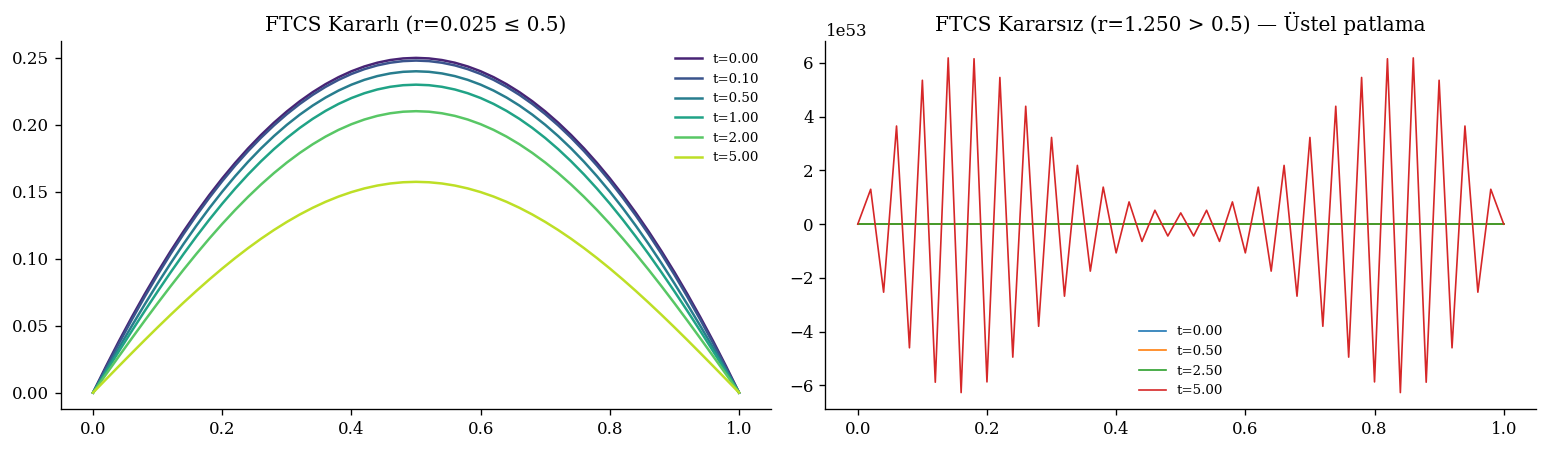

In [3]:
def ftcs_isi(u0, alpha, L, T, Nx, Nt):
    """
    u_t = alpha*u_xx için FTCS açık şeması.
    Çözüm dizisi (Nt+1, Nx+1) ve Fourier sayısı r döndürür.
    """
    dx = L / Nx; dt = T / Nt
    r = alpha * dt / dx**2
    x = np.linspace(0, L, Nx+1)

    U = np.zeros((Nt+1, Nx+1))
    U[0] = u0(x)
    U[:, 0] = 0; U[:, -1] = 0  # Dirichlet SK'ları

    for n in range(Nt):
        U[n+1, 1:-1] = (r * U[n, :-2] +
                        (1 - 2*r) * U[n, 1:-1] +
                        r * U[n, 2:])
    return x, U, r


u0 = lambda x: x * (1 - x)   # BK: parabol

# Kararlı çalışma (r < 0.5)
x_k, U_kararli, r_k = ftcs_isi(u0, alpha=0.01, L=1, T=5, Nx=50, Nt=5000)
# Kararsız çalışma (r > 0.5)
x_ka, U_kararsiz, r_ka = ftcs_isi(u0, alpha=0.01, L=1, T=5, Nx=50, Nt=100)

print(f"Kararlı çalışma:   r = {r_k:.4f} ({'<= 0.5 ✓' if r_k <= 0.5 else '> 0.5 ✗'})")
print(f"Kararsız çalışma:  r = {r_ka:.4f} ({'<= 0.5 ✓' if r_ka <= 0.5 else '> 0.5 ✗'})")

fig, eksenler = plt.subplots(1, 2, figsize=(13, 4))
t_cizim_idx = [0, 100, 500, 1000, 2000, 5000]
t_degerleri = np.linspace(0, 5, 5001)
renkler = cm.viridis(np.linspace(0.1, 0.9, len(t_cizim_idx)))

for idx, c in zip(t_cizim_idx, renkler):
    eksenler[0].plot(x_k, U_kararli[idx], color=c, lw=1.5, label=f't={t_degerleri[idx]:.2f}')
eksenler[0].set_title(f'FTCS Kararlı (r={r_k:.3f} ≤ 0.5)')
eksenler[0].legend(frameon=False, fontsize=8)

for idx in [0, 10, 50, 100]:
    eksenler[1].plot(x_ka, U_kararsiz[idx], lw=1, label=f't={5*idx/100:.2f}')
eksenler[1].set_title(f'FTCS Kararsız (r={r_ka:.3f} > 0.5) — Üstel patlama')
eksenler[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

---

## 3. Crank-Nicolson — Koşulsuz Kararlı, 2. Mertebe

Uzay operatörünü $n$ ve $n+1$ zaman seviyeleri arasında ortalayın:

$$\frac{u_i^{n+1} - u_i^n}{k} = \frac{\alpha}{2}\left(\delta^2_x u_i^n + \delta^2_x u_i^{n+1}\right)$$

Bu, her zaman adımında üç köşegenli sistemi üretir:

$$-\frac{r}{2}u_{i-1}^{n+1} + (1+r)u_i^{n+1} - \frac{r}{2}u_{i+1}^{n+1} = \frac{r}{2}u_{i-1}^n + (1-r)u_i^n + \frac{r}{2}u_{i+1}^n$$

Mertebe: $O(k^2 + h^2)$. Kararlılık: koşulsuz (A-kararlı).

Crank-Nicolson: r = 1.25 (koşulsuz kararlı)


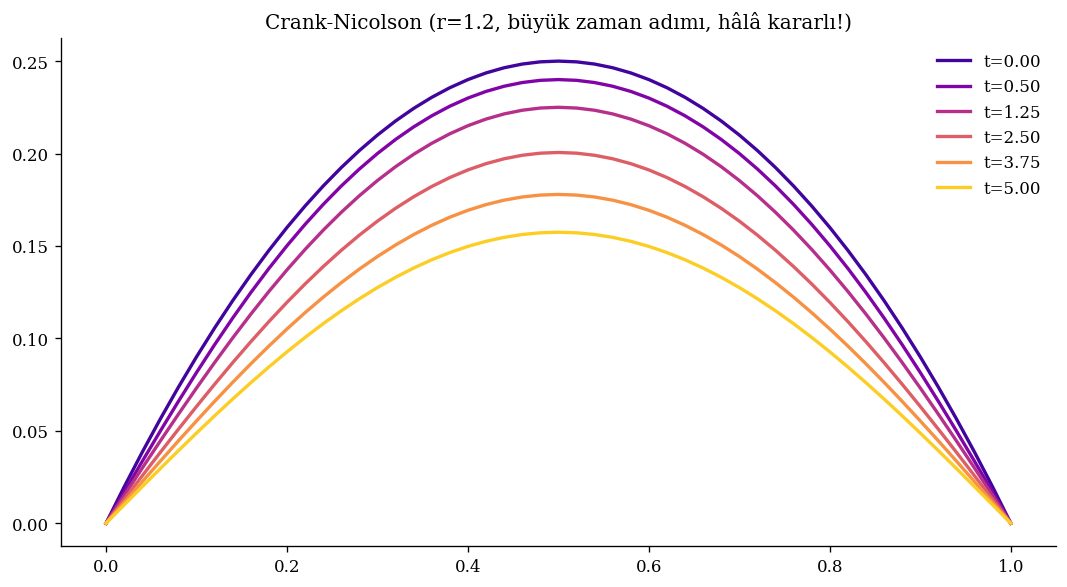

In [4]:
def thomas(a, b, c, d):
    """Üç köşegenli sistemler için Thomas algoritması."""
    n = len(b)
    c_ = np.zeros(n); d_ = np.zeros(n); x = np.zeros(n)
    c_[0] = c[0] / b[0]; d_[0] = d[0] / b[0]
    for i in range(1, n):
        payda = b[i] - a[i-1] * c_[i-1]
        c_[i] = (c[i] / payda) if i < n-1 else 0
        d_[i] = (d[i] - a[i-1] * d_[i-1]) / payda
    x[-1] = d_[-1]
    for i in range(n-2, -1, -1):
        x[i] = d_[i] - c_[i] * x[i+1]
    return x


def crank_nicolson_isi(u0, alpha, L, T, Nx, Nt):
    """u_t = alpha*u_xx için Crank-Nicolson şeması."""
    dx = L / Nx; dt = T / Nt
    r = alpha * dt / dx**2
    x = np.linspace(0, L, Nx+1)
    M = Nx - 1  # iç noktalar

    U = np.zeros((Nt+1, Nx+1))
    U[0] = u0(x)

    # Üç köşegen katsayıları (sabit)
    ana_kosegen = (1 + r) * np.ones(M)
    yan_kosegen = (-r/2)  * np.ones(M-1)

    for n in range(Nt):
        un_ic = U[n, 1:-1]
        sag = (r/2 * np.pad(un_ic, (0,1))[1:M+1] +   # sağa kaydır
               (1-r) * un_ic +
               r/2 * np.pad(un_ic, (1,0))[:M])         # sola kaydır
        # SK katkıları
        sag[0]  += r/2 * U[n, 0]   + r/2 * U[n+1, 0]
        sag[-1] += r/2 * U[n, -1]  + r/2 * U[n+1, -1]

        U[n+1, 1:-1] = thomas(yan_kosegen, ana_kosegen, yan_kosegen, sag)
    return x, U, r


# Büyük dt ile CN (r >> 0.5)
x_cn, U_cn, r_cn = crank_nicolson_isi(u0, alpha=0.01, L=1, T=5, Nx=50, Nt=100)
print(f"Crank-Nicolson: r = {r_cn:.2f} (koşulsuz kararlı)")

fig, ax = plt.subplots(figsize=(9, 5))
renkler = cm.plasma(np.linspace(0.1, 0.9, 6))
for idx, c in zip([0, 10, 25, 50, 75, 100], renkler):
    ax.plot(x_cn, U_cn[idx], color=c, lw=2, label=f't={5*idx/100:.2f}')
ax.set_title(f'Crank-Nicolson (r={r_cn:.1f}, büyük zaman adımı, hâlâ kararlı!)')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

---

## 4. Dalga Denklemi — Sıçrama Şeması

1B dalga denklemi:

$$\frac{\partial^2 u}{\partial t^2} = c^2\,\frac{\partial^2 u}{\partial x^2}$$

Hem zamanda hem uzayda merkezi farklar **sıçrama (leapfrog) şemasını** verir:

$$u_i^{n+1} = 2u_i^n - u_i^{n-1} + \nu^2\left(u_{i-1}^n - 2u_i^n + u_{i+1}^n\right)$$

burada $\nu = c\Delta t/\Delta x$ **Courant sayısı**dır. $\nu \leq 1$ ise kararlıdır (CFL koşulu).

Courant sayısı nu = 1.000 (<= 1 ✓)

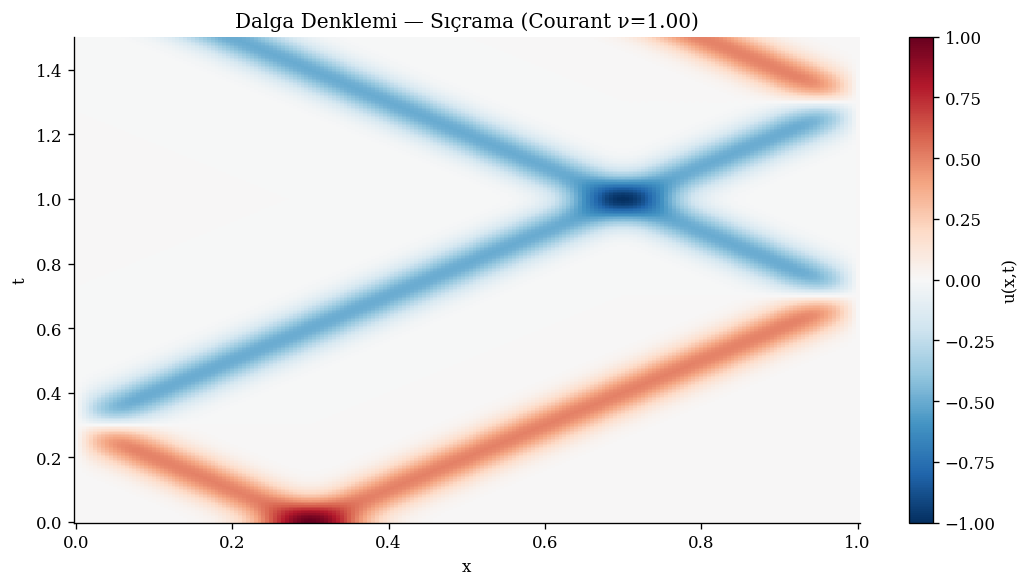

In [5]:
def sicrama_dalga(u0_fonk, du0_fonk, c, L, T, Nx, Nt):
    """
    u_tt = c^2*u_xx için sıçrama (ikinci mertebe merkezi) şeması.
    u0_fonk:  başlangıç yer değiştirmesi u(x,0)
    du0_fonk: başlangıç hızı  du/dt(x,0)
    """
    dx = L / Nx; dt = T / Nt
    nu = c * dt / dx
    x = np.linspace(0, L, Nx+1)

    U = np.zeros((Nt+1, Nx+1))
    U[0] = u0_fonk(x)

    # İlk zaman adımı Taylor açılımıyla: u^1 = u^0 + dt*ut^0 + dt^2/2 * u_tt^0
    u0 = U[0].copy()
    # u_tt^0 = c^2 * u_xx^0  (merkezi fark kullan)
    uxx0 = np.zeros(Nx+1)
    uxx0[1:-1] = (u0[:-2] - 2*u0[1:-1] + u0[2:]) / dx**2
    U[1, 1:-1] = (u0[1:-1] + dt * du0_fonk(x[1:-1]) +
                  0.5 * dt**2 * c**2 * uxx0[1:-1])

    for n in range(1, Nt):
        U[n+1, 1:-1] = (2 * U[n, 1:-1] - U[n-1, 1:-1] +
                        nu**2 * (U[n, :-2] - 2*U[n, 1:-1] + U[n, 2:]))
        U[n+1, 0] = U[n+1, -1] = 0  # Dirichlet

    return x, U, nu


# [0,1] üzerinde Gauss darbesi
c_dalga = 1.0
u0_gauss = lambda x: np.exp(-200*(x - 0.3)**2)
du0_sifir = lambda x: np.zeros_like(x)

x_d, U_dalga, nu = sicrama_dalga(u0_gauss, du0_sifir, c_dalga, L=1, T=1.5, Nx=200, Nt=300)
print(f"Courant sayısı nu = {nu:.3f} ({'<= 1 ✓' if nu <= 1 else '> 1 KARARSIZ ✗'})")

# Uzay-zaman grafiği (Hovmöller diyagramı)
t_dalga = np.linspace(0, 1.5, 301)
fig, ax = plt.subplots(figsize=(9, 5))
im = ax.pcolormesh(x_d, t_dalga, U_dalga, cmap='RdBu_r',
                   vmin=-1, vmax=1, shading='auto')
plt.colorbar(im, ax=ax, label='u(x,t)')
ax.set_xlabel('x'); ax.set_ylabel('t')
ax.set_title(f'Dalga Denklemi — Sıçrama (Courant ν={nu:.2f})')
plt.tight_layout(); plt.show()

---

## 5. Alıştırmalar

1. **(Isı denklemi)** Analitik Fourier serisi çözümünün, terim terim türevlenerek ısı denklemini sağladığını gösterin. FTCS hatasının $O(\Delta t + \Delta x^2)$ olduğunu sayısal doğrulayın.

2. **(Von Neumann kararlılığı)** $u_j^n = \xi^n e^{i j k h}$ yerine koyarak FTCS şeması için Von Neumann kararlılık analizini yapın ve büyütme faktörü $\xi(k, r)$'yi bulun.

3. **(CN mertebe doğrulaması)** $\Delta x$'i sabitleyip $\Delta t$'yi değiştirin; Crank-Nicolson hatasının $O(\Delta t^2)$ olarak azaldığını doğrulayın. Sonra $\Delta t$'yi sabitleyip $\Delta x$'i değiştirerek $O(\Delta x^2)$'yi doğrulayın.

4. **(d'Alembert)** Dalga denkleminin analitik çözümü $u(x,t) = F(x-ct) + G(x+ct)$'dir. Gauss darbesi BK'sının zıt yönlerde yayılan iki dalgaya ayrıldığını gösterin. Bunu sıçrama çıktısına karşı doğrulayın.

5. **(2B ısı denklemi)** FTCS'yi 2B'ye genişletin: birim kare üzerinde sıfır Dirichlet SK'ları ve BK $u_0 = \sin(\pi x)\sin(\pi y)$ ile $u_t = \alpha(u_{xx} + u_{yy})$. Uygulayın ve analitik çözüme karşı doğrulayın.
